In [36]:
import numpy as np, pandas as pd,matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report




In [37]:
df=pd.read_excel("Online Retail.xlsx")

print(df.head())

print(df.info())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       -----------

In [38]:
df=df.dropna(subset=["CustomerID"])
df=df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df=df[df["Quantity"]>0]
df=df[df["UnitPrice"]>0]
df["TotalAmount"]=df["Quantity"]*df["UnitPrice"]



In [39]:
print(df.shape)
print(df.head())


(397884, 9)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalAmount  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom        15.30  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom        22.00  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34  


In [40]:
customer_data=df.groupby("CustomerID").agg(
    TotalSpend=("TotalAmount","sum"),
    TotalQuantity=("Quantity","sum"),
    NoofTranscactions=("InvoiceNo","nunique"),
    NoofProducts=("StockCode","nunique"),
    AvgOrderValue=("TotalAmount","mean"),
    Country=("Country","first")
).reset_index()
print(customer_data.head())



   CustomerID  TotalSpend  TotalQuantity  NoofTranscactions  NoofProducts  \
0     12346.0    77183.60          74215                  1             1   
1     12347.0     4310.00           2458                  7           103   
2     12348.0     1797.24           2341                  4            22   
3     12349.0     1757.55            631                  1            73   
4     12350.0      334.40            197                  1            17   

   AvgOrderValue         Country  
0   77183.600000  United Kingdom  
1      23.681319         Iceland  
2      57.975484         Finland  
3      24.076027           Italy  
4      19.670588          Norway  


In [41]:
customer_data["Segment"]=pd.qcut(
    customer_data["TotalSpend"],
    q=3,
    labels=["lowValue","MediumValue","HighValue"]
)
print(customer_data["Segment"].value_counts())


    

Segment
lowValue       1446
MediumValue    1446
HighValue      1446
Name: count, dtype: int64


In [42]:
features=["TotalQuantity","NoofTranscactions","NoofProducts","AvgOrderValue"]
X=customer_data[features]
Y=customer_data["Segment"]

In [49]:
X_train,X_test,Y_train,Y_test=train_test_split(
    X,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=42
)

In [50]:
id3= DecisionTreeClassifier(
    criterion="entropy",
    random_state=42,
    max_depth=4
)

id3.fit(X_train,Y_train)
y_pred=id3.predict(X_test)

print("Predictions")
print(y_pred[:20])
    

Predictions
['MediumValue' 'lowValue' 'MediumValue' 'MediumValue' 'MediumValue'
 'HighValue' 'MediumValue' 'HighValue' 'HighValue' 'lowValue'
 'MediumValue' 'lowValue' 'HighValue' 'HighValue' 'HighValue' 'HighValue'
 'MediumValue' 'MediumValue' 'lowValue' 'MediumValue']


In [51]:
accuracy=accuracy_score(Y_test,y_pred)
print(f"Accuracy:{accuracy*100}")
print(f"Classification Report:\n{classification_report(Y_test,y_pred)}")
print(f"Confusion Matrix:\n{confusion_matrix(Y_test,y_pred)}")


Accuracy:85.36866359447005
Classification Report:
              precision    recall  f1-score   support

   HighValue       0.89      0.88      0.89       289
 MediumValue       0.77      0.82      0.79       289
    lowValue       0.90      0.86      0.88       290

    accuracy                           0.85       868
   macro avg       0.86      0.85      0.85       868
weighted avg       0.86      0.85      0.85       868

Confusion Matrix:
[[255  32   2]
 [ 28 236  25]
 [  2  38 250]]


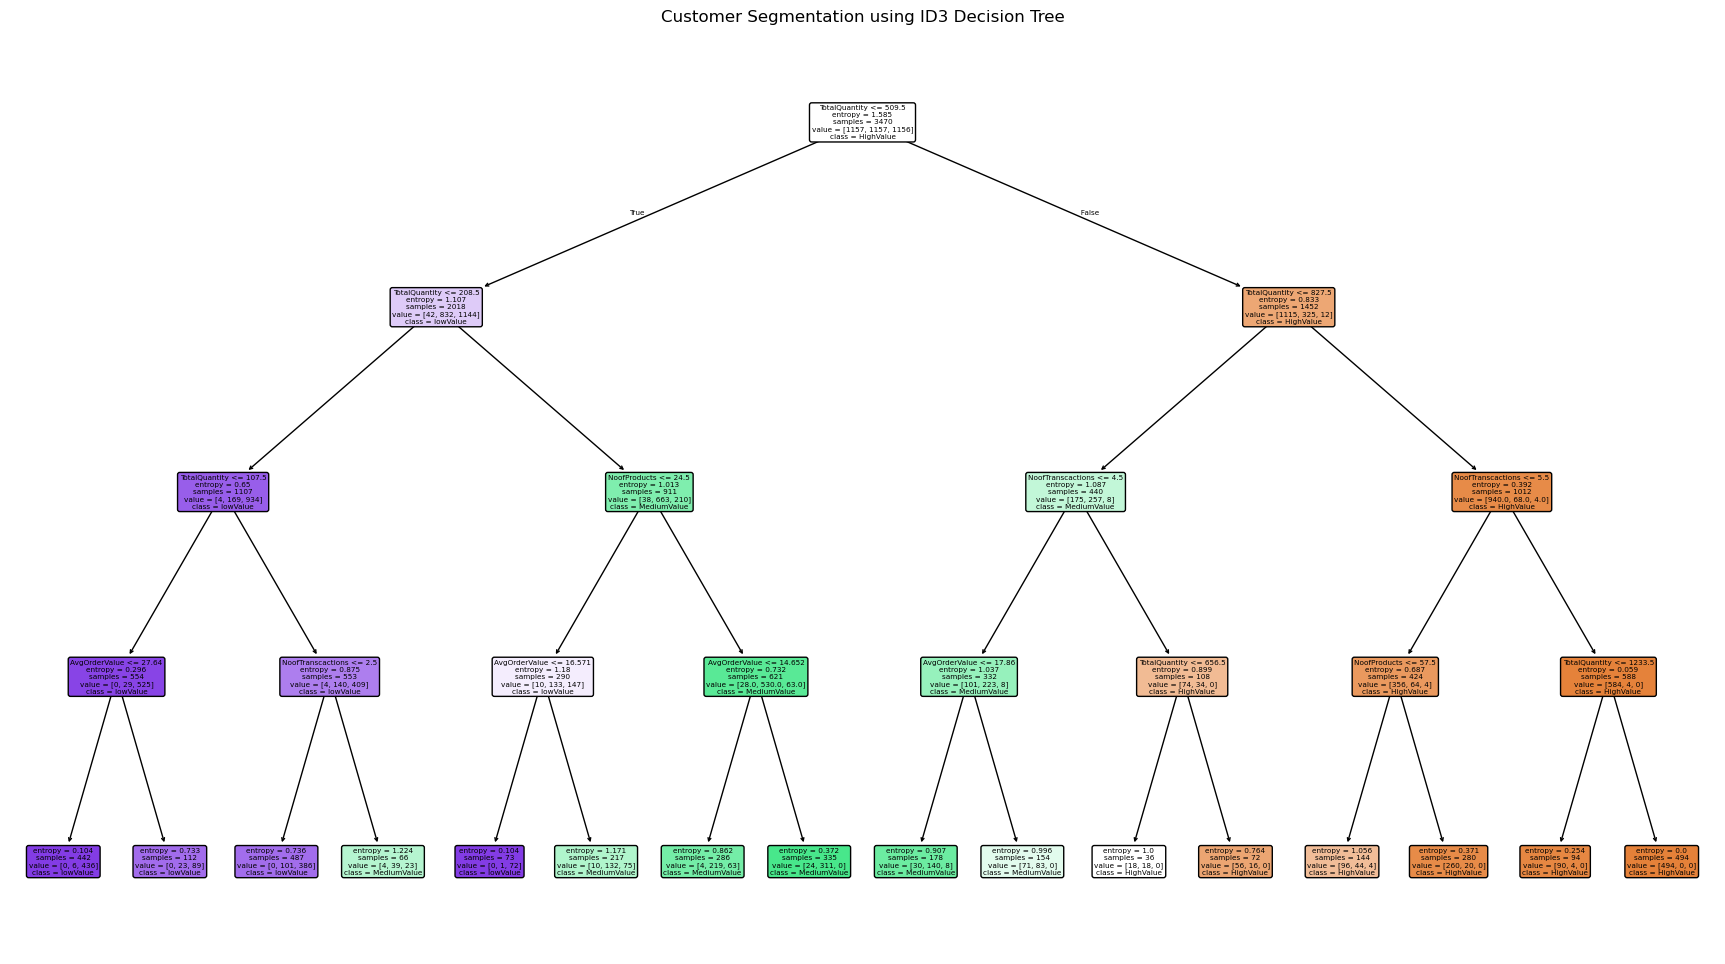

In [53]:
importance=pd.DataFrame({
    "Feature":features,
    "Importance":id3.feature_importances_
})

importance_sorted=importance.sort_values("Importance",ascending=True)

plt.figure(figsize=(22,12))

plot_tree(
    id3,
    feature_names=features,
    class_names=id3.classes_,
    filled=True,
    rounded=True,
    proportion=False
)
plt.title("Customer Segmentation using ID3 Decision Tree")
plt.show()

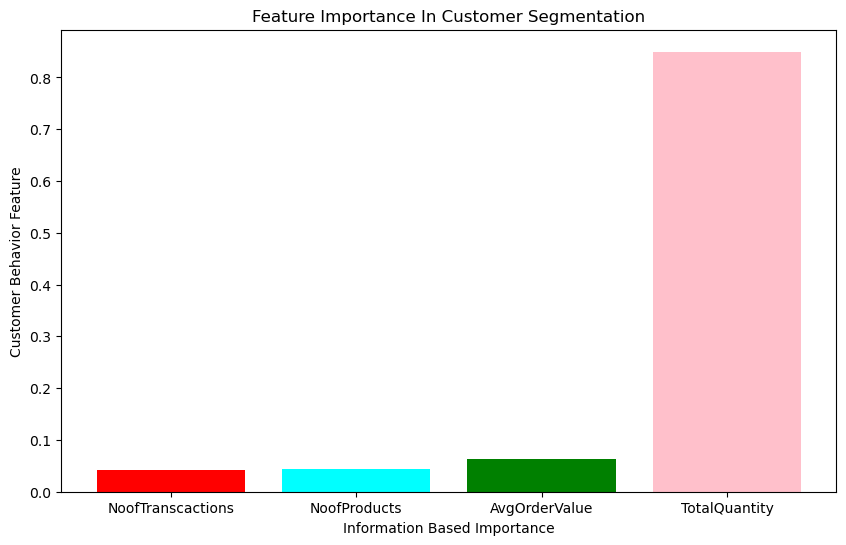

In [57]:
plt.figure(figsize=(10,6))
importance_sorted=importance.sort_values("Importance",ascending=True)
plt.bar(
    importance_sorted["Feature"],
    importance_sorted["Importance"],
    color=["red","cyan","green","pink"]
)

plt.xlabel("Information Based Importance")
plt.ylabel("Customer Behavior Feature")
plt.title("Feature Importance In Customer Segmentation")
plt.show()
    
